In [1]:
import torch
from torch import nn

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
import requests 
import zipfile
from pathlib import Path

data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print(f"{image_path} directory already exists, skipping download.")
else:
    print(f"{image_path} directory does not exist, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
with open (data_path/"pizza_steak_sushi.zip","wb") as f:
    requests = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print("downloading pizza steak sushi dataset...")
    f.write(requests.content)

with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip","r") as zip_ref:
    print("extracting pizza steak sushi dataset...")
    zip_ref.extractall(image_path)

data/pizza_steak_sushi directory already exists, skipping download.
downloading pizza steak sushi dataset...
extracting pizza steak sushi dataset...


In [4]:
import os 
def walk_through_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [5]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.


In [6]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [7]:
import random
from PIL import Image
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list

[PosixPath('data/pizza_steak_sushi/train/steak/2648423.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/914570.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/2254705.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/167069.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/421476.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/1621763.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/1225762.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/2287136.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/3142674.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/165639.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/3518960.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/355715.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/1598345.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/97656.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/2606444.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/1647351.jpg'),
 PosixPath('dat

Random Image path: data/pizza_steak_sushi/test/sushi/1245193.jpg
Random Image class: sushi
Image hieght: 295
Image width: 512


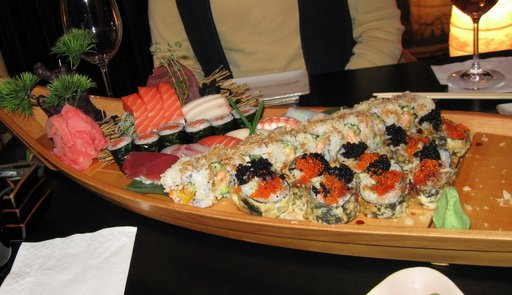

In [8]:
random_image_path = random.choice(image_path_list)
random_image_path

image_class = random_image_path.parent.stem
img = Image.open(random_image_path)

print(f"Random Image path: {random_image_path}")
print(f"Random Image class: {image_class}")
print(f"Image hieght: {img.height}")
print(f"Image width: {img.width}")
img

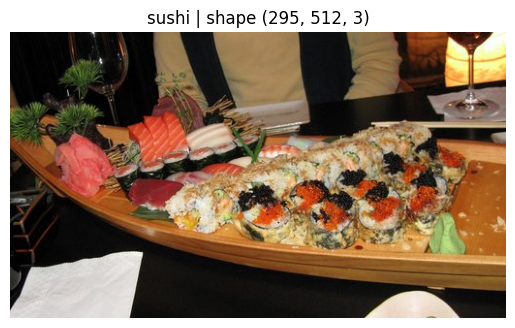

In [9]:
import numpy as np 
import matplotlib.pyplot as plt
img_array = np.array(img)
plt.imshow(img_array)
plt.title(f"{image_class} | shape {img_array.shape}")
plt.axis(False)
plt.show()

In [10]:
import torch 
from torch.utils.data import DataLoader
from  torchvision  import datasets, transforms

In [11]:
data_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToTensor()
])

In [12]:
data_transform(img)

tensor([[[0.9804, 0.8431, 0.2745,  ..., 0.0118, 0.0118, 0.0157],
         [0.9882, 0.9686, 0.5725,  ..., 0.0118, 0.0118, 0.0157],
         [0.9843, 0.9882, 0.8941,  ..., 0.0078, 0.0118, 0.0157],
         ...,
         [0.0588, 0.0706, 0.0824,  ..., 0.8549, 0.8314, 0.6549],
         [0.0784, 0.0902, 0.0980,  ..., 0.8627, 0.8510, 0.8275],
         [0.0824, 0.0902, 0.0980,  ..., 0.8549, 0.8510, 0.8510]],

        [[0.9882, 0.8235, 0.1843,  ..., 0.0118, 0.0118, 0.0157],
         [0.9961, 0.9647, 0.4863,  ..., 0.0118, 0.0118, 0.0157],
         [0.9922, 0.9961, 0.8627,  ..., 0.0078, 0.0118, 0.0157],
         ...,
         [0.0588, 0.0706, 0.0784,  ..., 0.8392, 0.8157, 0.6392],
         [0.0784, 0.0863, 0.0863,  ..., 0.8471, 0.8431, 0.8118],
         [0.0784, 0.0863, 0.0902,  ..., 0.8431, 0.8471, 0.8353]],

        [[0.9020, 0.7373, 0.1216,  ..., 0.0118, 0.0118, 0.0157],
         [0.9451, 0.9059, 0.4078,  ..., 0.0118, 0.0118, 0.0157],
         [0.8667, 0.9608, 0.8118,  ..., 0.0078, 0.0118, 0.

In [13]:
def plot_transformed_image(image_paths: list,transform, n=3,seed=None ):
    if seed:
        random.seed(seed)
    random_image_path = random.sample(image_paths,k=n)
    for image_path in random_image_path:
        with Image.open(image_path) as img:
           fig, ax = plt.subplots(ncols=2, figsize=(10,5))
           ax[0].imshow(img)
           ax[0].set_title(f"Original image: {img.size}")
           ax[0].axis(False)


           ax[1].imshow(transform(img).permute(1,2,0))
           ax[1].set_title(f"Transformed image: {transform(img).shape}")
           ax[1].axis(False)

           fig.suptitle(f"{image_path.parent.stem} | {image_path.name}")

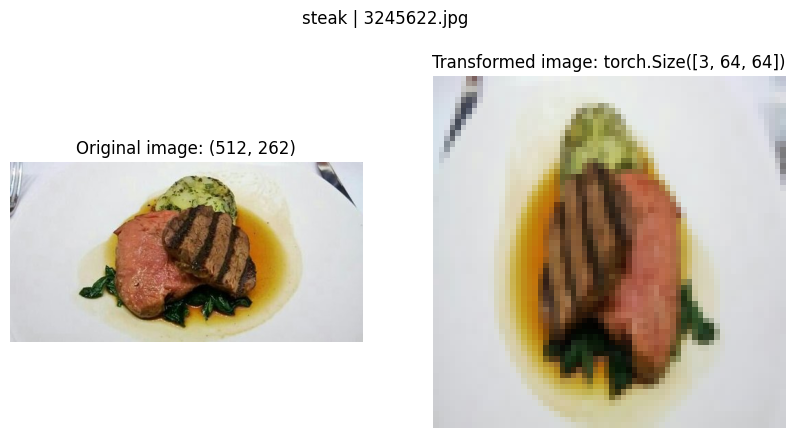

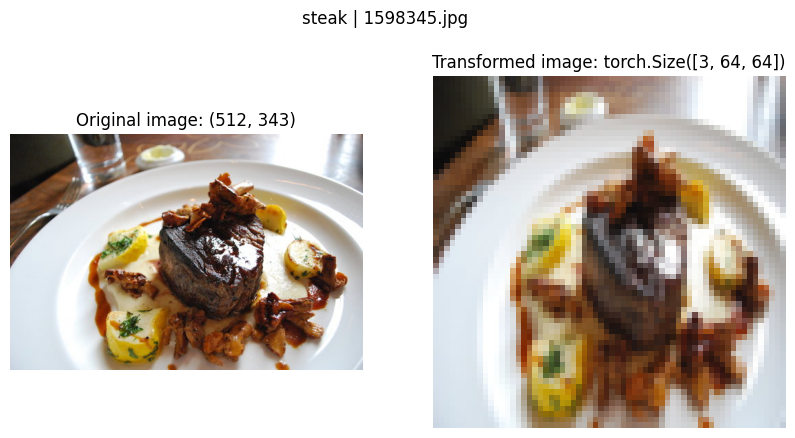

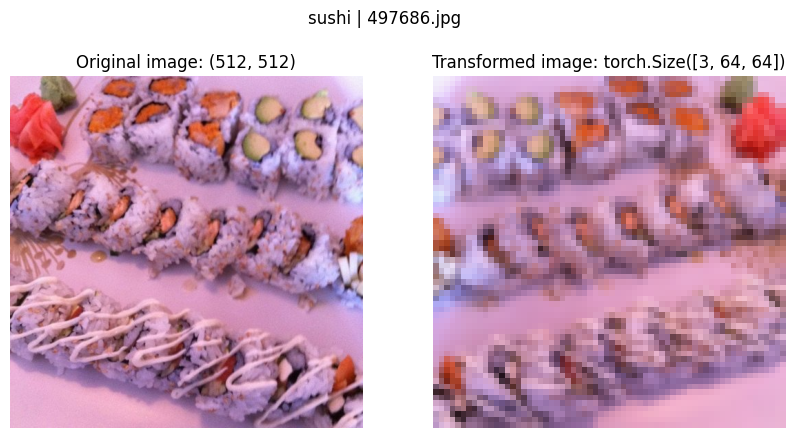

In [14]:
plot_transformed_image(image_path_list, data_transform, n=3, seed=42)

In [15]:
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform,
                                  target_transform=None)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [16]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [17]:
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [18]:
train_data.samples[:5]

[('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0),
 ('data/pizza_steak_sushi/train/pizza/1033251.jpg', 0),
 ('data/pizza_steak_sushi/train/pizza/1044789.jpg', 0),
 ('data/pizza_steak_sushi/train/pizza/1089334.jpg', 0),
 ('data/pizza_steak_sushi/train/pizza/1105700.jpg', 0)]

In [19]:
img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label index: {label}")
print(f"Label dtype: {type(label)}")    

Image tensor:
tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.09

Permuted image shape: torch.Size([64, 64, 3])


Text(0.5, 1.0, 'Image label: pizza')

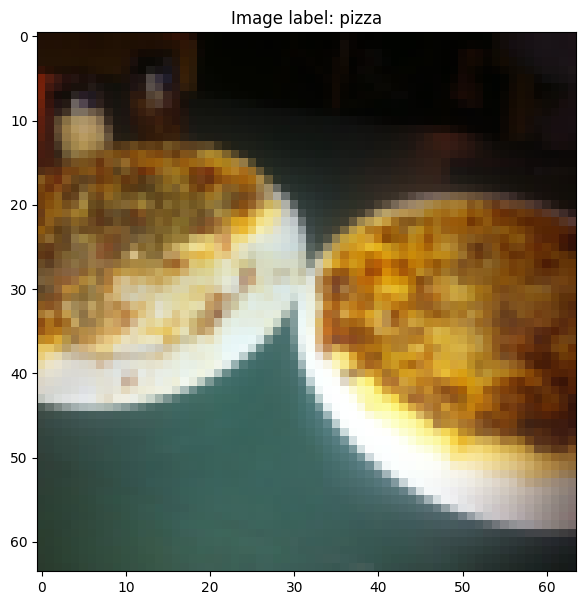

In [20]:
image_permuted = img.permute(1,2,0)
print(f"Permuted image shape: {image_permuted.shape}")
plt.figure(figsize=(10,7))
plt.imshow(image_permuted)
plt.title(f"Image label: {class_names[label]}")

In [21]:
# Create DataLoader
train_dataloader = DataLoader(train_data, batch_size=32,num_workers=1, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=32,num_workers=1, shuffle=False) 

In [22]:
os.cpu_count()

8

In [23]:
len(train_dataloader), len(test_dataloader)

(8, 3)

In [24]:
import os 
import pathlib

from  PIL import Image
from torch.utils.data import dataset
from torchvision import  transforms
from typing import Tuple, List, Dict

In [25]:
target_directory = train_dir
print(f"Target directory: {target_directory}")

class_names_found = sorted ([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

Target directory: data/pizza_steak_sushi/train


['pizza', 'steak', 'sushi']

In [26]:
def find_classes_in_target_directory(target_directory: str) -> Tuple [List[str], Dict[str, int]]:
    target_directory = pathlib.Path(target_directory)
    class_names_found = sorted ([entry.name for entry in list(os.scandir(target_directory))])
    if not class_names_found:
        raise FileNotFoundError(f"Couldn't find any classes in {target_directory}")
    class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names_found)}
    return class_names_found, class_to_idx

In [27]:
find_classes_in_target_directory(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [35]:
from torch.utils.data import Dataset
class ImageFolderCustom(Dataset):
    def __init__(self, targ_dir: str, transform=None):
        # 1. Properly initialize path and find classes
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
        self.transform = transform # Fixed naming from 'truncate'
        
        # Note: You'll need to define this function or use torchvision's helper
        self.classes, self.class_to_idx = self._find_classes(targ_dir) 

    def _find_classes(self, directory: str) -> Tuple[List[str], Dict[str, int]]:
        # Simple implementation of class finding
        classes = sorted([entry.name for entry in pathlib.Path(directory).iterdir() if entry.is_dir()])
        class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
        return classes, class_to_idx

    def load_image(self, index: int) -> Image.Image:
        image_path = self.paths[index]
        return Image.open(image_path)
            
    def __len__(self) -> int:
        return len(self.paths)
            
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        image = self.load_image(index)
        
        # 2. Correctly access the path for the class name
        image_path = self.paths[index] 
        class_name = image_path.parent.name # 'name' or 'stem' works for folders
        class_idx = self.class_to_idx[class_name]

        # 3. Apply transform if it exists
        if self.transform:
            return self.transform(image), class_idx
        
        # Warning: If no transform is provided, this returns a PIL Image, 
        # which will fail in a default PyTorch DataLoader.
        return image, class_idx


In [36]:
train_transform = transforms.Compose([transforms.Resize((64,64)),
                                        transforms.RandomHorizontalFlip(p=0.5),
                                        transforms.ToTensor()])

In [37]:
test_transform = transforms.Compose([transforms.Resize((64,64)),
                                        transforms.ToTensor()])

In [38]:
train_data_custom = ImageFolderCustom(train_dir, transform=train_transform)
test_data_custom = ImageFolderCustom(test_dir, transform=test_transform)

In [39]:
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7ee2c4987150>,
 <__main__.ImageFolderCustom at 0x7ee28f454350>)

In [40]:
from torch.utils.data import DataLoader

train_dataloader_custom = DataLoader(train_data_custom, 
                                     batch_size=32,
                                     num_workers=1, 
                                     shuffle=True)

test_dataloader_custom = DataLoader(test_data_custom,
                                    batch_size=32,
                                    num_workers=1, 
                                    shuffle=False)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7ee2c4995ed0>,
 <torch.utils.data.dataloader.DataLoader at 0x7ee2c49946d0>)

In [41]:
img_custom, label_custom = next(iter(train_dataloader_custom))
img_custom.shape, label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [43]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor() ])


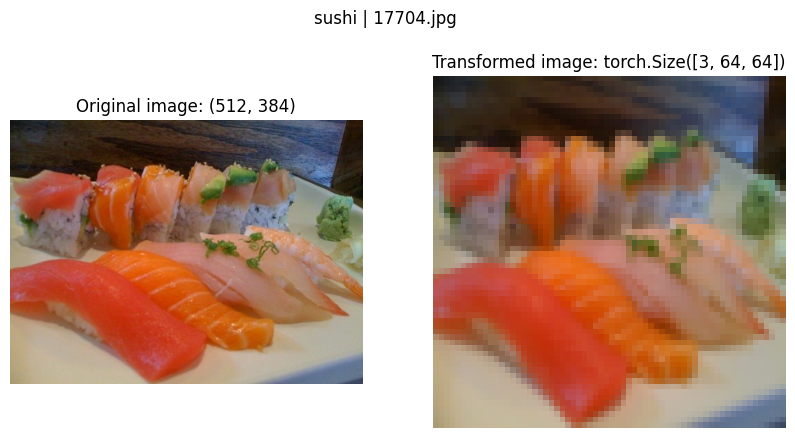

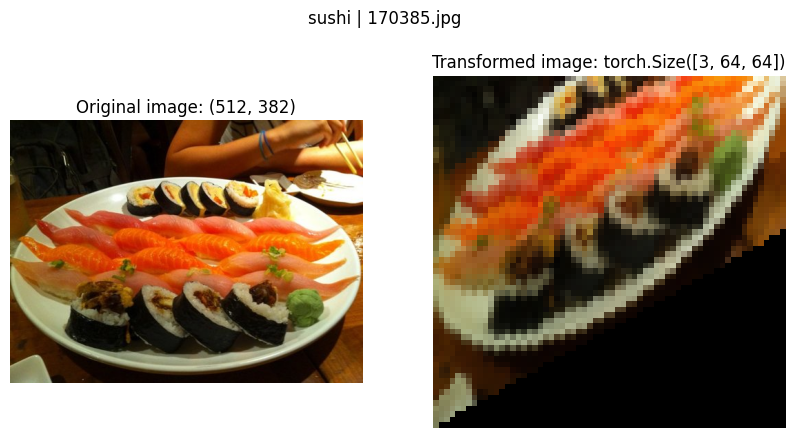

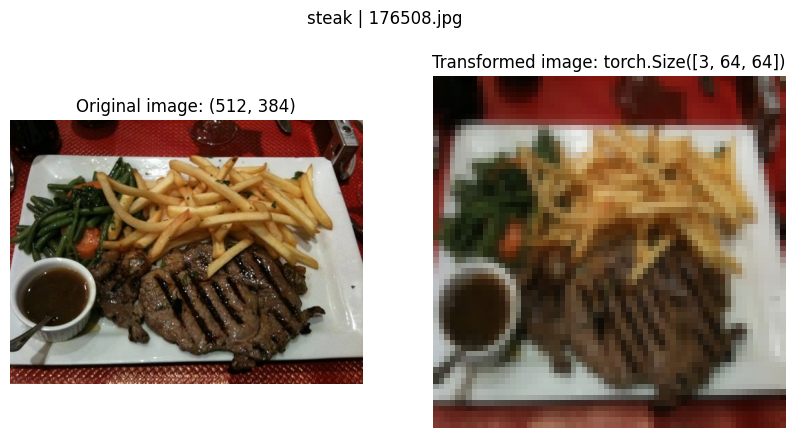

In [45]:
plot_transformed_image(image_path_list, train_transform, n=3, seed=None)

In [46]:
simple_transform = transforms.Compose([ transforms.Resize((64,64)),
                                            transforms.ToTensor()])

In [48]:
train_data_simple = datasets.ImageFolder(root=train_dir, transform=simple_transform)

test_data_simple = datasets.ImageFolder(root=test_dir, transform=simple_transform)

In [53]:
train_dataloader_simple = DataLoader(train_data_simple, batch_size=32, num_workers=1, shuffle=True)
test_dataloader_simple = DataLoader(test_data_simple, batch_size=32, num_workers=1, shuffle=False)

In [59]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units*2, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units*2, out_channels=hidden_units*2, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=(hidden_units*2)*13*13, out_features=output_shape)
        )

    def forward(self,x):
        x = self.conv_block_1(x)
        print(x.shape)
        x = self.conv_block_2(x)
        print(x.shape)
        x = self.classifier(x)
        print(x.shape)
        return x

In [60]:
model_0 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(class_names)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 20, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3380, out_features=3, bias=True)
  )
)

In [54]:
image_batch , label_batch = next(iter(train_dataloader_simple))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [61]:
model_0(image_batch.to(device))

torch.Size([32, 10, 30, 30])
torch.Size([32, 20, 13, 13])
torch.Size([32, 3])


tensor([[ 2.0734e-02, -4.9237e-03, -1.9672e-03],
        [ 2.8688e-02, -5.2848e-03, -4.7323e-03],
        [ 3.1590e-02, -8.5177e-03, -1.1033e-02],
        [ 3.0208e-02, -5.7053e-03, -8.5885e-03],
        [ 2.4762e-02, -1.6619e-02, -4.3401e-03],
        [ 3.3267e-02, -1.4963e-02, -3.7278e-03],
        [ 3.3169e-02, -2.6957e-03, -1.5013e-02],
        [ 2.9395e-02, -9.6894e-03, -7.0812e-03],
        [ 3.2119e-02, -1.1232e-02, -4.1595e-03],
        [ 3.7383e-02, -2.3896e-02, -3.8771e-05],
        [ 3.3159e-02, -9.3488e-03, -7.8973e-03],
        [ 2.9830e-02,  4.7689e-03, -1.1468e-02],
        [ 2.5559e-02, -7.5884e-03,  1.1150e-02],
        [ 3.6247e-02, -2.5605e-02,  3.4630e-03],
        [ 3.6882e-02, -2.1117e-02, -2.8966e-04],
        [ 2.8785e-02, -5.5285e-03, -5.0721e-03],
        [ 2.6135e-02, -9.2658e-03,  2.7955e-03],
        [ 3.1218e-02, -7.2941e-03, -3.2979e-03],
        [ 3.1733e-02, -1.9869e-02, -2.9157e-04],
        [ 3.6126e-02, -7.9817e-03,  1.9428e-03],
        [ 2.4862e-02